In [1]:
import pandas as pd
import numpy as np
print("Pandas version:", pd.__version__)
print("Numpy version:", np.__version__)

Pandas version: 2.3.3
Numpy version: 2.2.6


In [5]:
data = pd.DataFrame({
    "Size": [1500, 1700, 1800, 2000, 2100, 3000, 4000, 5000],
    "Bedrooms": [3, 3, 4, 4, 5, 6, 4, 5],
    "Price": [4000000, 4300000, 6000000, 5500000, 8000000, 9000000, 7500000, 8500000]
})

In [6]:
data.head()

,Size,Bedrooms,Price
0,1500,3,4000000
1,1700,3,4300000
2,1800,4,6000000
3,2000,4,5500000
4,2100,5,8000000


In [8]:
print(data.isnull().sum())

Size        0
Bedrooms    0
Price       0
dtype: int64


In [10]:
print(data.describe())

              Size  Bedrooms         Price
count     8.000000  8.000000  8.000000e+00
mean   2637.500000  4.250000  6.600000e+06
std    1261.447581  1.035098  1.918333e+06
min    1500.000000  3.000000  4.000000e+06
25%    1775.000000  3.750000  5.200000e+06
50%    2050.000000  4.000000  6.750000e+06
75%    3250.000000  5.000000  8.125000e+06
max    5000.000000  6.000000  9.000000e+06


In [12]:
X = data[['Size', 'Bedrooms']]  # Input features
y = data['Price']  

In [14]:
pip install scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 93.0 MB/s eta 0:00:00:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 kB 59.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.7/37.7 MB 34.4 MB/s eta 0:00:0000:0100:01

[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (6, 2)
Test size: (2, 2)


In [16]:
from sklearn.linear_model import LinearRegression

# Create model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

# Coefficients
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Coefficients: [4.38740364e+02 1.64433328e+06]
Intercept: -1467278.9896670515


In [17]:
y_pred = model.predict(X_test)

# Compare predictions vs actual
df_compare = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
df_compare

,Actual,Predicted
1,4300000,4.211579e+06
5,9000000,9.714942e+06


In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 401681.15466623055
MSE: 259479966042.39438
RMSE: 509391.76087015227
R²: 0.9530140396482762


In [20]:
pip install matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 98.0 MB/s eta 0:00:00:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 127.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 115.7 MB/s eta 0:00:0000:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.0/325.0 kB 44.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.8/121.8 kB 21.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 135.7 MB/s eta 0:00:0000:01

[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


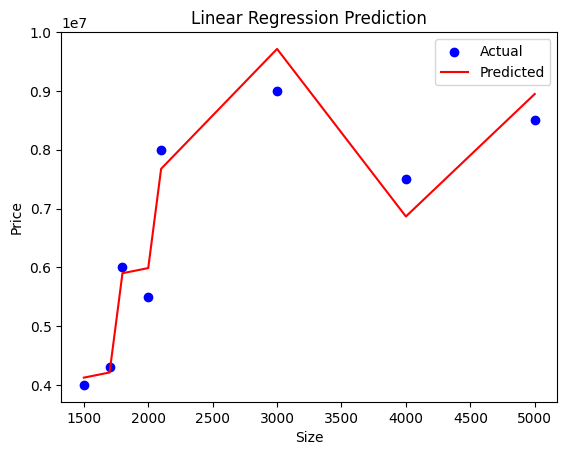

In [22]:
import matplotlib.pyplot as plt

plt.scatter(data['Size'], data['Price'], color='blue', label='Actual')
plt.plot(data['Size'], model.predict(data[['Size','Bedrooms']]), color='red', label='Predicted')
plt.xlabel("Size")
plt.ylabel("Price")
plt.title("Linear Regression Prediction")
plt.legend()
plt.show()

In [23]:
import pickle

# Save model
with open('linear_model.pkl', 'wb') as f:
    pickle.dump(model, f)

In [ ]:
from flask import Flask, request, jsonify
import pickle
import numpy as np

app = Flask(__name__)

# Load the trained model
with open("linear_model.pkl", "rb") as f:
    model = pickle.load(f)

@app.route("/predict", methods=["POST"])
def predict():
    data = request.json
    features = np.array([[data['Size'], data['Bedrooms']]])
    prediction = model.predict(features)[0]
    return jsonify({"Predicted Price": prediction})

if __name__ == "__main__":
    app.run(host="0.0.0.0", port=5000)

 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://172.17.0.2:5000
Press CTRL+C to quit
